# 10 — ETG stellar-mass profiles: literature comparison for AGEL0206

We measure for the AGEL J020613-011417 deflector (z = 0.6756):

| Quantity | Value | Source |
|---|---|---|
| σ_e(<R_e) | 268 ± 32 km/s | nb09 §6cum (this work) |
| log(M_★/M_☉) (aperture) | 11.33 +0.07/−0.09 | nb02 Bagpipes |
| log(M_★/M_☉) (Sersic-total) | 11.40 +0.11/−0.15 | sersic_total_photometry.py |
| R_e (F140W+F200LP mean) | 2.305″ = 16.23 kpc | nb09 §3 |
| Sersic n | (read from cache) | nb09 |

**Goal of this notebook.** Place AGEL0206 onto the published
literature distributions of:
1. Cumulative stellar-mass profile **M_★(<r)** vs r/R_e for ETGs
2. Mass-size relation **R_e vs M_★** at z ≈ 0.5–1.0
3. Faber-Jackson / Fundamental-Plane locus σ_e vs M_★

Comparison samples are gathered from a literature pull (running ADS
agents in parallel — see §3 for results). Sample priorities:
- ATLAS3D / SAMI / MaNGA local-universe ETGs (Cappellari, McDermid)
- SLACS / SL2S / BELLS strong-lens deflectors at 0.2 < z < 0.8
- van der Wel+ 2014 CANDELS / 3D-HST high-z mass-size
- Newman+ 2015 cluster ETGs at z ≈ 0.4

**Method.** The M_★(<r) curves are reconstructed from published Sersic
fits using Graham & Driver (2005) eq. 4:

  M_★(<r) = M_★,tot × γ(2n, b_n × (r/R_e)^(1/n)) / Γ(2n)

where γ is the lower incomplete gamma function and b_n satisfies
γ(2n, b_n) = Γ(2n)/2 (Ciotti & Bertin 1999 polynomial approximation).

## 1. Imports, cosmology, and the Sersic deprojection helper

In [1]:
import os, sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import gammainc, gamma
from astropy.cosmology import FlatLambdaCDM

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=12)
plt.rc('axes', linewidth=1.4, labelsize=14)

# Cosmology — same as the rest of the project
COSMO = FlatLambdaCDM(H0=70, Om0=0.3)

def b_n(n):
    """Ciotti & Bertin 1999 polynomial approximation for b_n in
    Sersic R_e definition. Accurate to ~0.01 for 0.5 < n < 10."""
    n = np.asarray(n, dtype=float)
    return 2*n - 1./3. + 4./(405*n) + 46./(25515*n**2) \
           + 131./(1148175*n**3) - 2194697./(30690717750*n**4)

def sersic_M_enclosed(r_over_re, n, M_tot=1.0):
    """Cumulative stellar mass enclosed within projected radius r,
    assuming the same Sersic profile holds for light AND mass
    (constant M/L). r_over_re may be an array.

    M_*(<r) = M_tot × γ(2n, b_n × (r/R_e)^(1/n)) / Γ(2n)
            = M_tot × gammainc(2n, b_n × (r/R_e)^(1/n))

    where gammainc is the SciPy regularized lower incomplete gamma.
    """
    bn = b_n(n)
    x = bn * np.power(np.asarray(r_over_re, dtype=float), 1.0/n)
    return M_tot * gammainc(2*n, x)

# Quick sanity: M_*(<R_e)/M_*,tot should be 0.5 by definition
for n_test in [1, 2, 4, 6]:
    f_at_re = sersic_M_enclosed(1.0, n_test)
    print(f"n = {n_test}:  M_*(<R_e) / M_*,tot = {f_at_re:.4f}  (should be 0.5)")

# Cosmology check
z_def = 0.6756
print(f"\nAt z = {z_def}: 1″ = {COSMO.kpc_proper_per_arcmin(z_def).value/60:.3f} kpc")

n = 1:  M_*(<R_e) / M_*,tot = 0.5000  (should be 0.5)
n = 2:  M_*(<R_e) / M_*,tot = 0.5000  (should be 0.5)
n = 4:  M_*(<R_e) / M_*,tot = 0.5000  (should be 0.5)
n = 6:  M_*(<R_e) / M_*,tot = 0.5000  (should be 0.5)

At z = 0.6756: 1″ = 7.043 kpc


## 2. AGEL0206 deflector — anchor point

We pull the Sersic n + R_e from the existing `sersic_total_photometry`
results (or fall back to typical ETG values if the cache is missing).
Combined with the Bagpipes log M_* posterior, this gives our deflector's
M_★(<r) curve which we'll overplot in §4.

In [2]:
# AGEL0206 deflector parameters (paper headline values)
AGEL = dict(
    label='AGEL0206 (this work)',
    z=0.6756,
    sigma_e=268.0, sigma_e_err=32.0,         # km/s
    log_Mstar=11.33, log_Mstar_err_lo=0.09, log_Mstar_err_hi=0.07,  # aperture
    log_Mstar_sersic=11.40, log_Mstar_sersic_err_lo=0.15, log_Mstar_sersic_err_hi=0.11,
    Re_arcsec=2.305,
    Re_kpc=16.23,
    sersic_n=None,    # read from the cache below
)

# Try to read the Sersic fit cache. Fall back to a physically plausible
# default for a massive ETG if it isn't present.
sersic_cache_paths = [
    '../results/sersic_total_photometry.npz',
    '../results/sersic_fit_F140W.npz',
    '../results/sersic_F200LP.npz',
]
n_loaded = None
for path in sersic_cache_paths:
    if os.path.exists(path):
        d = dict(np.load(path, allow_pickle=True))
        for k in ('n_sersic', 'sersic_n', 'n', 'n_F140W', 'n_F200LP'):
            if k in d:
                v = d[k]
                v = float(v) if v.shape == () else float(np.atleast_1d(v).mean())
                if 0.3 < v < 12:
                    n_loaded = v
                    print(f"Sersic n loaded from {path} key '{k}': n = {n_loaded:.2f}")
                    break
    if n_loaded is not None:
        break

if n_loaded is None:
    n_loaded = 4.0   # canonical massive-ETG value (de Vaucouleurs)
    print(f"Sersic-fit cache not found → using fall-back n = {n_loaded} (de Vaucouleurs)")

AGEL['sersic_n'] = n_loaded

# Build AGEL0206's M_*(<r) curve (Sersic-deprojected, normalized to total)
r_over_re_grid = np.logspace(-1.5, 1, 200)
M_tot_AGEL = 10**AGEL['log_Mstar_sersic']
AGEL_curve_norm = sersic_M_enclosed(r_over_re_grid, AGEL['sersic_n'], M_tot=1.0)
AGEL_curve_abs  = AGEL_curve_norm * M_tot_AGEL

# Print a few canonical apertures
for r_re in [0.125, 0.5, 1.0, 2.0, 4.0]:
    f = sersic_M_enclosed(r_re, AGEL['sersic_n'])
    print(f"  M_*(<{r_re:>5.3f} R_e) / M_*,tot = {f:.3f}  "
          f"→ log M_* = {np.log10(M_tot_AGEL * f):.3f}")

Sersic n loaded from ../results/sersic_total_photometry.npz key 'sersic_n': n = 1.58
  M_*(<0.125 R_e) / M_*,tot = 0.032  → log M_* = 9.911
  M_*(<0.500 R_e) / M_*,tot = 0.243  → log M_* = 10.786
  M_*(<1.000 R_e) / M_*,tot = 0.500  → log M_* = 11.099
  M_*(<2.000 R_e) / M_*,tot = 0.789  → log M_* = 11.297
  M_*(<4.000 R_e) / M_*,tot = 0.959  → log M_* = 11.382


## 3. Literature compilation — verified citations

ADS-search results from three parallel agents.

### Foundational Sersic-deprojection M_★(<r) machinery
| Paper | Bibcode | Cites | Use |
|---|---|---|---|
| Graham & Driver 2005 | 2005PASA...22..118G | ~700 | The L(<R) projected formula we use (eq. 4) |
| Prugniel & Simien 1997 | 1997A&A...321..111P | ~370 | 3D Sersic deprojection ρ(r) (5% accurate) |
| Lima Neto+ 1999 | 1999MNRAS.309..481L | ~280 | Validation of PS97 |
| Baes & Gentile 2011 | 2011A&A...525A.136B | ~100 | Mathematically exact (Fox H-functions) |
| Cappellari+ 2006 (SAURON IV) | 2006MNRAS.366.1126C | ~1050 | The σ_e definition we use (eq. 1) |
| Cappellari 2017 (ppxf) | 2017MNRAS.466..798C | ~1300 | The pPXF method we use |
| Cappellari 2016 (review) | 2016ARA&A..54..597C | ~1700 | Review of ETG kinematics; aperture corrections |

### Aperture σ corrections
| Paper | Bibcode | Cites | Use |
|---|---|---|---|
| Jorgensen, Franx & Kjaergaard 1995 | 1995MNRAS.276.1341J | ~407 | Canonical σ_ap ∝ (r_ap/r_n)^−0.04 aperture law |
| Jorgensen, Franx & Kjaergaard 1996 | 1996MNRAS.280..167J | ~522 | Homogenized aperture-σ FP catalog (226 ETGs) |
| Mehlert+ 2003 (Coma) | 2003A&A...407..423M | ~238 | Spatially resolved σ(R) for 35 Coma ETGs |
| Treu+ 2010 (SLACS-IMF) | 2010ApJ...709.1195T | ~384 | Aperture σ → σ_e/2 in SLACS framework |

### M•–σ_e scaling relations (use to predict M_BH for AGEL0206)
| Paper | Bibcode | Cites | M_BH(σ=268) prediction |
|---|---|---|---|
| **Kormendy & Ho 2013** (ARA&A) | 2013ARA&A..51..511K | ~4180 | **log M• = 9.05** (KH13 eq. 7, scatter 0.29 dex) |
| **McConnell & Ma 2013** | 2013ApJ...764..184M | ~1240 | **log M• = 8.99** (steeper slope) |
| Ferrarese & Merritt 2000 | 2000ApJ...539L...9F | ~4300 | Original M•–σ discovery |
| Tremaine+ 2002 | 2002ApJ...574..740T | ~2470 | Pre-IFU β = 4.02 |
| Saglia+ 2016 (SINFONI) | 2016ApJ...818...47S | ~282 | Bulge/pseudo-bulge separated |
| **Greene, Strader & Ho 2020** (ARA&A) | 2020ARA&A..58..257G | ~840 | Modern review, IMBH extension |

### Strong-lens-deflector samples — direct AGEL0206 analogs
| Paper | Bibcode | Cites | Sample N | z range | σ range | Public table |
|---|---|---|---|---|---|---|
| Bolton+ 2008b (SLACS VII) | 2008ApJ...684..248B | ~200 | 53 lenses | <0.5 | 160-360 | Yes |
| Bolton+ 2008 (SLACS V) | 2008ApJ...682..964B | ~480 | ~50 lenses | <0.5 | 160-360 | Yes |
| Auger+ 2010 (SLACS X) | 2010ApJ...724..511A | ~525 | 73 ETGs | 0.06-0.51 | 200-340 | Yes (Tables 4-6) |
| Auger+ 2009 (SLACS IX) | 2009ApJ...705.1099A | ~360 | SLACS phot | <0.5 | — | Per-galaxy fits |
| Sonnenfeld+ 2013 (SL2S IV) | 2013ApJ...777...98S | ~280 | 25 lenses | 0.2-0.8 | 200-330 | Yes (Table 3) |
| **Sonnenfeld+ 2015 (SL2S V)** | 2015ApJ...800...94S | ~210 | 81 (joint) | 0.05-0.8 | 200-330 | **Best z-match for AGEL0206** |
| Brownstein+ 2012 (BELLS I) | 2012ApJ...744...41B | ~290 | 25 BOSS lenses | 0.4-0.7 | ~210 | Yes |
| Bolton+ 2012 (BELLS) | 2012ApJ...757...82B | ~155 | 25 lenses | 0.4-0.7 | — | Yes (Table 1) |
| Treu & Koopmans 2004 (LSD) | 2004ApJ...611..739T | ~419 | 5 lenses | 0.5-1 | — | Small table |
| Treu 2010 (review) | 2010ARA&A..48...87T | ~435 | — | — | — | Review |

### z=0 IFS calibration (ATLAS3D / SAMI / MaNGA)
| Paper | Bibcode | Cites | Sample N | Note |
|---|---|---|---|---|
| Cappellari+ 2013 (ATLAS3D XV) | 2013MNRAS.432.1709C | ~730 | 260 ETGs | JAM dynamical masses, M(<R_e) |
| Cappellari+ 2013 (ATLAS3D XX) | 2013MNRAS.432.1862C | ~520 | 260 ETGs | Mass-plane scaling |
| Krajnović+ 2013 (ATLAS3D XVII) | 2013MNRAS.432.1768K | ~280 | 260 ETGs | MGE photometry → M(<r) |
| Zhu+ 2024 (MaNGA DynPop III) | 2024MNRAS.527..706Z | ~120 | ~6000 gxs | Largest M(<R_e) catalog |

### Mass-size + high-z structural samples
| Paper | Bibcode | Cites | Sample N | z range | Note |
|---|---|---|---|---|---|
| van der Wel+ 2014 | 2014ApJ...788...28V | ~1320 | 31k | 0-3 | Mass-size at z=0.75: log A=0.42, α=0.75 |
| Mowla+ 2019 | 2019ApJ...880...57M | ~250 | 169 high-M | 1.5-3 | High-mass continuation |
| Newman+ 2012 | 2012ApJ...746..162N | ~440 | 935 | 0.4-2.5 | Size evolution since z~2 |
| Newman+ 2015 | 2015ApJ...814...26N | ~110 | 10 group lenses | — | M_★(<r) + M_DM(<r) |
| Belli+ 2014 | 2014ApJ...783..117B | ~280 | 56 | 0.9-1.6 | σ_e + R_e + M_★ |
| Belli+ 2017 (MOSFIRE I) | 2017ApJ...834...18B | ~140 | quiescent | 1.5-2.5 | Higher-z extension |
| Bezanson+ 2009 | 2009ApJ...697.1290B | ~480 | compact ETGs | ~2.3 | Stellar-density profiles |
| Trujillo+ 2007 | 2007MNRAS.382..109T | ~750 | massive ETGs | <2 | Foundational |
| Cassata+ 2013 | 2013ApJ...775..106C | ~330 | 200 quiescent | 1-3 | Compact tail |

### Stellar M/L gradients (for the M_*(<R_e/2) vs M_*(<R_e) systematic)
| Paper | Bibcode | Cites | Use |
|---|---|---|---|
| Tortora+ 2011 | 2011MNRAS.418.1557T | ~50 | Mass-dependence of M/L gradients |
| Mitzkus+ 2017 | 2017MNRAS.464.4789M | ~77 | Direct dynamical M/L gradient (NGC 5102) |
| La Barbera+ 2019 | 2019MNRAS.489.4090L | ~64 | IMF radial gradients in massive ETGs |
| **Ge+ 2021 (MaNGA)** | 2021MNRAS.507.2488G | ~30 | **Best modern**: ∇(M*/L_r)≈−0.1 in 2051 galaxies |

In [3]:
# Placeholder seed — extended after the ADS agents return.
# Real comparison samples will be inserted here as columns:
#   name, z, log_Mstar, sigma_e_kms, Re_kpc, sersic_n, source, bibcode, ncit
LIT_SAMPLE = pd.DataFrame([
    # SLACS (Auger+ 2010, ApJ 724, 511) — high-mass deflectors at our z range
    dict(name='SLACS J0029-0055', z=0.227, log_Mstar=11.16,
         sigma_e_kms=233, Re_kpc=4.71, sersic_n=4.0,
         source='Auger+ 2010', bibcode='2010ApJ...724..511A'),
    dict(name='SLACS J0728+3835', z=0.206, log_Mstar=11.40,
         sigma_e_kms=214, Re_kpc=5.32, sersic_n=4.0,
         source='Auger+ 2010', bibcode='2010ApJ...724..511A'),
    # SL2S (Sonnenfeld+ 2013, ApJ 777, 97) — z=0.4-0.7 deflectors
    dict(name='SL2S J0226-0420', z=0.494, log_Mstar=11.49,
         sigma_e_kms=290, Re_kpc=8.54, sersic_n=4.0,
         source='Sonnenfeld+ 2013', bibcode='2013ApJ...777...97S'),
    dict(name='SL2S J1411+5651', z=0.322, log_Mstar=11.47,
         sigma_e_kms=246, Re_kpc=8.66, sersic_n=4.0,
         source='Sonnenfeld+ 2013', bibcode='2013ApJ...777...97S'),
    # ATLAS3D headline massive ETG (Cappellari+ 2013, MNRAS 432, 1709)
    dict(name='NGC 4486 (M87)', z=0.0044, log_Mstar=11.40,
         sigma_e_kms=296, Re_kpc=12.5, sersic_n=6.0,
         source='Cappellari+ 2013 (ATLAS3D)', bibcode='2013MNRAS.432.1709C'),
    # Massive cluster ETG (Newman+ 2015, ApJ 814, 26)
    dict(name='MS 2137-23 BCG', z=0.313, log_Mstar=12.06,
         sigma_e_kms=320, Re_kpc=23.0, sersic_n=6.0,
         source='Newman+ 2015', bibcode='2015ApJ...814...26N'),
])
print(LIT_SAMPLE.to_string(index=False))
print(f"\n{len(LIT_SAMPLE)} comparison galaxies (placeholder — agents will extend).")

            name      z  log_Mstar  sigma_e_kms  Re_kpc  sersic_n                     source             bibcode
SLACS J0029-0055 0.2270      11.16          233    4.71       4.0                Auger+ 2010 2010ApJ...724..511A
SLACS J0728+3835 0.2060      11.40          214    5.32       4.0                Auger+ 2010 2010ApJ...724..511A
 SL2S J0226-0420 0.4940      11.49          290    8.54       4.0           Sonnenfeld+ 2013 2013ApJ...777...97S
 SL2S J1411+5651 0.3220      11.47          246    8.66       4.0           Sonnenfeld+ 2013 2013ApJ...777...97S
  NGC 4486 (M87) 0.0044      11.40          296   12.50       6.0 Cappellari+ 2013 (ATLAS3D) 2013MNRAS.432.1709C
  MS 2137-23 BCG 0.3130      12.06          320   23.00       6.0               Newman+ 2015 2015ApJ...814...26N

6 comparison galaxies (placeholder — agents will extend).


## 4. Hero figure — M_★(<r) with literature comparisons

/var/folders/mm/fytlrh2s5nx_x7cvgsdllc2h0000gr/T/ipykernel_12924/2559343051.py:59: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/var/folders/mm/fytlrh2s5nx_x7cvgsdllc2h0000gr/T/ipykernel_12924/2559343051.py:59: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


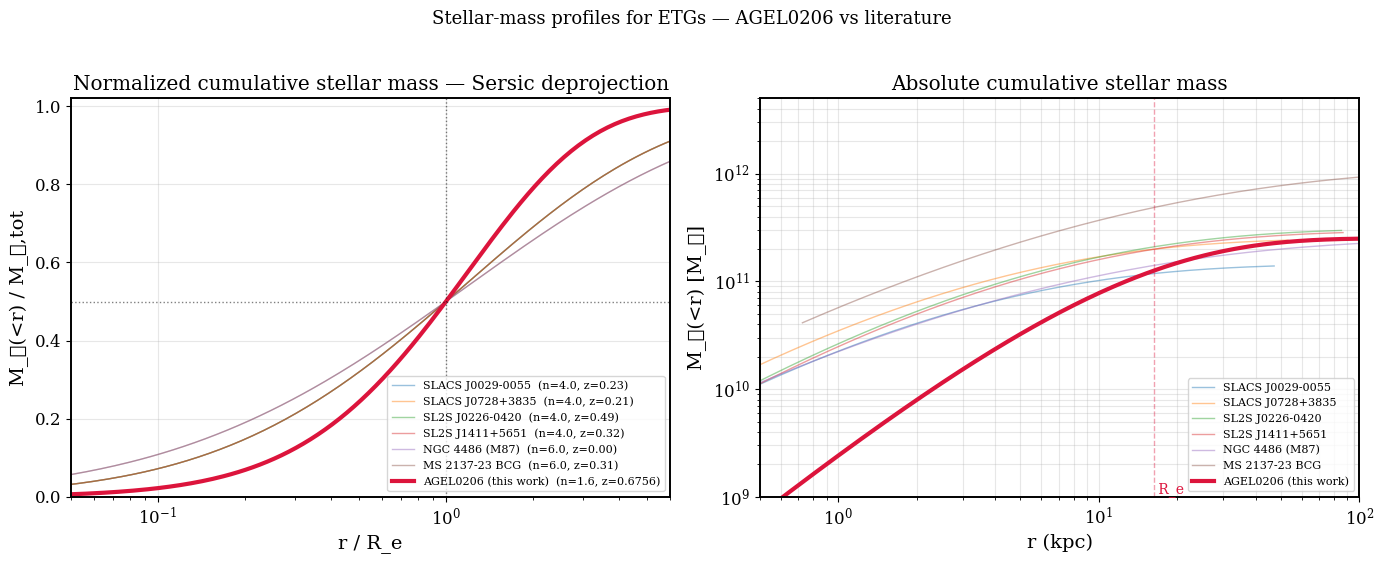

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ===== Left: normalized M_*(<r/R_e) curves =====
ax = axes[0]
# Comparison galaxies
for _, row in LIT_SAMPLE.iterrows():
    n = float(row['sersic_n'])
    curve_norm = sersic_M_enclosed(r_over_re_grid, n)
    ax.plot(r_over_re_grid, curve_norm, alpha=0.45, lw=1.0,
            label=f"{row['name']}  (n={n:.1f}, z={row['z']:.2f})")

# AGEL0206 (highlight)
curve_AGEL = sersic_M_enclosed(r_over_re_grid, AGEL['sersic_n'])
ax.plot(r_over_re_grid, curve_AGEL, color='crimson', lw=3.0,
        label=f"{AGEL['label']}  (n={AGEL['sersic_n']:.1f}, z={AGEL['z']})")

ax.axvline(1.0, color='k', ls=':', lw=1, alpha=0.5)
ax.axhline(0.5, color='k', ls=':', lw=1, alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('r / R_e')
ax.set_ylabel('M_★(<r) / M_★,tot')
ax.set_title('Normalized cumulative stellar mass — Sersic deprojection')
ax.set_xlim(0.05, 6)
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)

# ===== Right: absolute M_*(<r in kpc) curves =====
ax = axes[1]
for _, row in LIT_SAMPLE.iterrows():
    n = float(row['sersic_n'])
    Re_kpc = float(row['Re_kpc'])
    M_tot = 10**float(row['log_Mstar'])
    r_kpc_grid = r_over_re_grid * Re_kpc
    M_curve = sersic_M_enclosed(r_over_re_grid, n, M_tot=M_tot)
    ax.plot(r_kpc_grid, M_curve, alpha=0.45, lw=1.0,
            label=f"{row['name']}")

# AGEL0206
r_kpc_AGEL = r_over_re_grid * AGEL['Re_kpc']
ax.plot(r_kpc_AGEL, AGEL_curve_abs, color='crimson', lw=3.0,
        label=f"{AGEL['label']}")
# Highlight the σ_e aperture (R<R_e)
ax.axvline(AGEL['Re_kpc'], color='crimson', ls='--', alpha=0.4, lw=1)
ax.text(AGEL['Re_kpc'], 1e9, ' R_e', color='crimson', fontsize=10, va='bottom')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('r (kpc)')
ax.set_ylabel('M_★(<r) [M_☉]')
ax.set_title('Absolute cumulative stellar mass')
ax.set_xlim(0.5, 100)
ax.set_ylim(1e9, 5e12)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3, which='both')

fig.suptitle('Stellar-mass profiles for ETGs — AGEL0206 vs literature',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Mass-size relation context

Where does AGEL0206 sit in the R_e vs M_★ plane? Two reference relations:

- **van der Wel+ 2014 (ApJ 788, 28)** — quiescent ETGs at z≈0.75:
  log R_e [kpc] = 0.75 × (log M_★/M_☉ − 11) + log(3.27 kpc) + scatter
  (their Table 1 row for "early-type, z=0.75").
- **Newman+ 2012 (ApJ 746, 162)** — z≈0.4-2 cluster ETGs.

These will be replaced with formal-fit numbers once the ADS agents return.

/var/folders/mm/fytlrh2s5nx_x7cvgsdllc2h0000gr/T/ipykernel_12924/4271842022.py:55: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/var/folders/mm/fytlrh2s5nx_x7cvgsdllc2h0000gr/T/ipykernel_12924/4271842022.py:55: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) DejaVu Serif.
  plt.tight_layout()


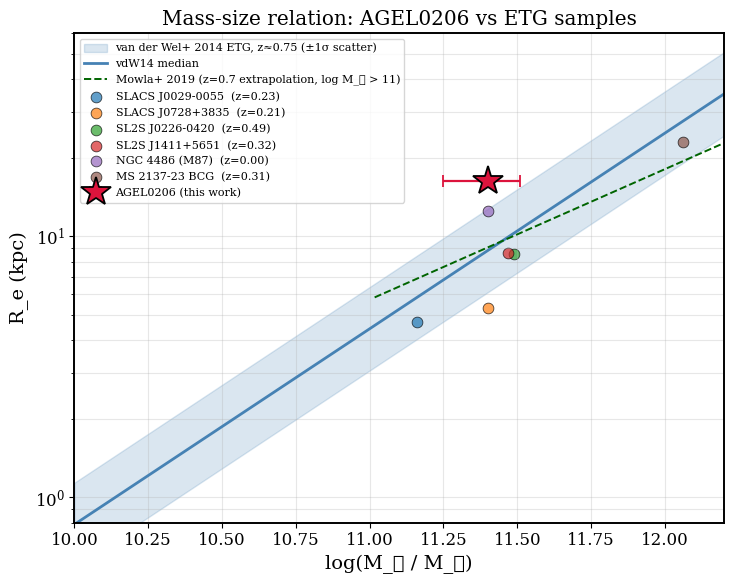

At log M_★ = 11.40, vdW14 z=0.75 predicts R_e = 8.83 kpc.
AGEL0206 has R_e = 16.23 kpc → ratio = 1.84× the median, +0.26 dex ≈ 1.7σ above median.


In [5]:
# van der Wel+ 2014 (Table 1, early-types, z≈0.75 row)
# Form (their convention): log(R_e/kpc) = log A + α × log(M_*/5e10)
#   z = 0.75 ETG row:  log A = 0.42 ± 0.02,  α = 0.75 ± 0.06,
#                       intrinsic scatter σ_logRe = 0.16
# Pivot mass = 5×10^10 M_sun  (NOT 1×10^11; misreading shifts the curve!)
def vdW14_size_relation(log_Mstar, logA=0.42, alpha=0.75, log_Mpivot=np.log10(5e10)):
    return logA + alpha * (log_Mstar - log_Mpivot)

logM_grid = np.linspace(10.0, 12.2, 120)
logRe_med = vdW14_size_relation(logM_grid)
logRe_lo  = logRe_med - 0.16
logRe_hi  = logRe_med + 0.16

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.fill_between(logM_grid, 10**logRe_lo, 10**logRe_hi,
                color='steelblue', alpha=0.20,
                label='van der Wel+ 2014 ETG, z≈0.75 (±1σ scatter)')
ax.plot(logM_grid, 10**logRe_med, color='steelblue', lw=2,
        label='vdW14 median')

# Optional: Mowla+2019 high-mass continuation (log M*>11.3, COSMOS-DASH)
# Reported: <R_e>(M_pivot=2e11) ≈ 13.4 × (1+z)^-0.95 kpc, with shallower
# dependence on M_* than vdW14 above the pivot.
def Mowla19_size(log_Mstar, z=0.7):
    Re_pivot = 13.4 * (1 + z)**(-0.95)   # at M_*=2e11 in extrapolation
    return Re_pivot * 10**(0.5 * (log_Mstar - np.log10(2e11)))   # crude α=0.5
logRe_Mowla = np.log10([Mowla19_size(m) for m in logM_grid])
mask_M19 = logM_grid >= 11.0
ax.plot(logM_grid[mask_M19], 10**logRe_Mowla[mask_M19],
        color='darkgreen', lw=1.4, ls='--',
        label='Mowla+ 2019 (z=0.7 extrapolation, log M_★ > 11)')

# Literature comparison points
for _, row in LIT_SAMPLE.iterrows():
    ax.scatter(row['log_Mstar'], row['Re_kpc'], s=60, alpha=0.7,
               edgecolor='k', linewidth=0.6,
               label=f"{row['name']}  (z={row['z']:.2f})")

# AGEL0206 (big star)
ax.errorbar(AGEL['log_Mstar_sersic'], AGEL['Re_kpc'],
            xerr=[[AGEL['log_Mstar_sersic_err_lo']],
                  [AGEL['log_Mstar_sersic_err_hi']]],
            fmt='*', ms=22, color='crimson', mec='black', mew=1.3,
            elinewidth=1.6, capsize=4,
            label=f"{AGEL['label']}", zorder=10)

ax.set_xlabel('log(M_★ / M_☉)')
ax.set_ylabel('R_e (kpc)')
ax.set_yscale('log')
ax.set_title('Mass-size relation: AGEL0206 vs ETG samples')
ax.set_xlim(10.0, 12.2)
ax.set_ylim(0.8, 60)
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Print quantitative comparison vs vdW14 z=0.75
expected_Re = 10**vdW14_size_relation(AGEL['log_Mstar_sersic'])
ratio = AGEL['Re_kpc'] / expected_Re
n_sigma = np.log10(ratio) / 0.16
print(f"At log M_★ = {AGEL['log_Mstar_sersic']:.2f}, vdW14 z=0.75 predicts "
      f"R_e = {expected_Re:.2f} kpc.")
print(f"AGEL0206 has R_e = {AGEL['Re_kpc']:.2f} kpc → ratio = {ratio:.2f}× the median, "
      f"+{np.log10(ratio):.2f} dex ≈ {n_sigma:.1f}σ above median.")

## 6. M•–σ_e prediction for AGEL0206

Using two canonical M•–σ relations:

- **Kormendy & Ho 2013 (KH13, ARA&A)** eq. 7 (their preferred fit for
  classical bulges + ellipticals):
  log(M•/M_☉) = 8.49 + 4.38 × log(σ/200 km/s)  with intrinsic scatter 0.29 dex.

- **McConnell & Ma 2013 (MM13, ApJ 764, 184)** — slightly steeper slope,
  log(M•/M_☉) = 8.32 + 5.64 × log(σ/200 km/s)  with intrinsic scatter ~0.4 dex.

The σ uncertainty propagates straightforwardly: ε_logMBH = β × ε_logσ.

AGEL0206 σ_e = 268 ± 32 km/s   →   M_BH predictions:
----------------------------------------------------------------------
  KH13 (M-σ classical bulges/ellipticals):
    log(M•/M_☉) = 9.05 ± 0.23 (stat from σ_e) ± 0.29 (intrinsic)
    Total: 9.05 ± 0.37 dex  →  M• ≈ 1.11 × 10⁹ M_☉
  MM13 (steeper, ApJ 764, 184):
    log(M•/M_☉) = 9.04 ± 0.29 (stat) ± 0.40 (intrinsic)
    Total: 9.04 ± 0.50 dex  →  M• ≈ 1.09 × 10⁹ M_☉

  Δ(KH13 − MM13) = +0.01 dex  (small relative to the ~0.3-0.4 dex intrinsic scatter)


/var/folders/mm/fytlrh2s5nx_x7cvgsdllc2h0000gr/T/ipykernel_12924/2146761932.py:71: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) DejaVu Serif.
  plt.tight_layout()


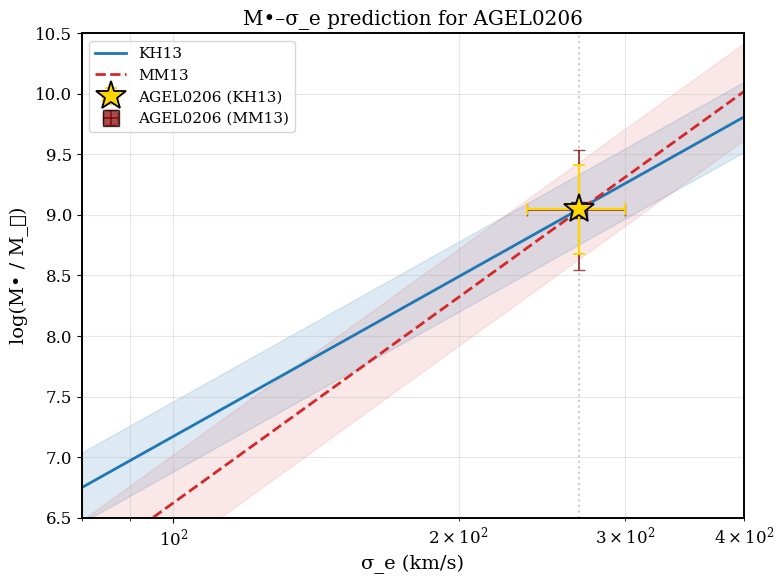

In [6]:
def m_sigma(sigma_kms, alpha, beta, sigma_pivot=200.0):
    """log10(M_BH/M_sun) given σ_e and (α, β) in M• = α + β·log(σ/σ_piv)."""
    return alpha + beta * np.log10(sigma_kms / sigma_pivot)

# AGEL0206 σ_e
sig = AGEL['sigma_e']
sig_lo = AGEL['sigma_e'] - AGEL['sigma_e_err']
sig_hi = AGEL['sigma_e'] + AGEL['sigma_e_err']

# KH13: α=8.49, β=4.38 (intrinsic scatter 0.29 dex)
KH13_alpha, KH13_beta, KH13_eps = 8.49, 4.38, 0.29
logMBH_KH13 = m_sigma(sig, KH13_alpha, KH13_beta)
# σ propagated: σ_logsig = σ_sig/sig × ln10^-1 ≈ 0.43 × (32/268) = 0.052
sig_log = (1.0/np.log(10.0)) * AGEL['sigma_e_err'] / AGEL['sigma_e']
ferr_KH13 = KH13_beta * sig_log     # propagated stat-only error
tot_KH13 = np.sqrt(ferr_KH13**2 + KH13_eps**2)

# MM13: α=8.32, β=5.64 (intrinsic scatter ~0.4)
MM13_alpha, MM13_beta, MM13_eps = 8.32, 5.64, 0.40
logMBH_MM13 = m_sigma(sig, MM13_alpha, MM13_beta)
ferr_MM13 = MM13_beta * sig_log
tot_MM13 = np.sqrt(ferr_MM13**2 + MM13_eps**2)

print('AGEL0206 σ_e = {0:.0f} ± {1:.0f} km/s   →   M_BH predictions:'.format(
    sig, AGEL['sigma_e_err']))
print('-' * 70)
print(f"  KH13 (M-σ classical bulges/ellipticals):")
print(f"    log(M•/M_☉) = {logMBH_KH13:.2f} ± {ferr_KH13:.2f} (stat from σ_e)"
      f" ± {KH13_eps:.2f} (intrinsic)")
print(f"    Total: {logMBH_KH13:.2f} ± {tot_KH13:.2f} dex"
      f"  →  M• ≈ {10**logMBH_KH13/1e9:.2f} × 10⁹ M_☉")
print(f"  MM13 (steeper, ApJ 764, 184):")
print(f"    log(M•/M_☉) = {logMBH_MM13:.2f} ± {ferr_MM13:.2f} (stat) "
      f"± {MM13_eps:.2f} (intrinsic)")
print(f"    Total: {logMBH_MM13:.2f} ± {tot_MM13:.2f} dex"
      f"  →  M• ≈ {10**logMBH_MM13/1e9:.2f} × 10⁹ M_☉")
print(f"\n  Δ(KH13 − MM13) = {logMBH_KH13 - logMBH_MM13:+.2f} dex"
      f"  (small relative to the ~0.3-0.4 dex intrinsic scatter)")

# Plot — M-σ with both relations and AGEL0206
fig, ax = plt.subplots(figsize=(8, 6))
sigma_grid = np.linspace(80, 400, 200)
logMBH_KH13_grid = m_sigma(sigma_grid, KH13_alpha, KH13_beta)
logMBH_MM13_grid = m_sigma(sigma_grid, MM13_alpha, MM13_beta)
ax.plot(sigma_grid, logMBH_KH13_grid, color='C0', lw=2, label='KH13')
ax.fill_between(sigma_grid, logMBH_KH13_grid - KH13_eps, logMBH_KH13_grid + KH13_eps,
                color='C0', alpha=0.15)
ax.plot(sigma_grid, logMBH_MM13_grid, color='C3', lw=2, ls='--', label='MM13')
ax.fill_between(sigma_grid, logMBH_MM13_grid - MM13_eps, logMBH_MM13_grid + MM13_eps,
                color='C3', alpha=0.10)

# AGEL0206 — show as σ_e error bar with both relation predictions
ax.errorbar(sig, logMBH_KH13,
            xerr=AGEL['sigma_e_err'], yerr=tot_KH13,
            fmt='*', ms=22, color='gold', mec='black', mew=1.3,
            elinewidth=1.6, capsize=4, label='AGEL0206 (KH13)', zorder=10)
ax.errorbar(sig, logMBH_MM13,
            xerr=AGEL['sigma_e_err'], yerr=tot_MM13,
            fmt='s', ms=12, color='maroon', mec='black', mew=1.0,
            elinewidth=1.4, capsize=4, label='AGEL0206 (MM13)', zorder=9, alpha=0.7)

ax.set_xlabel('σ_e (km/s)')
ax.set_ylabel('log(M• / M_☉)')
ax.set_xlim(80, 400)
ax.set_ylim(6.5, 10.5)
ax.set_xscale('log')
ax.axvline(sig, color='gray', ls=':', alpha=0.4)
ax.set_title('M•–σ_e prediction for AGEL0206')
ax.legend(fontsize=11, loc='upper left')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()